In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv("input_tokens.csv")

In [13]:
scam_cond = (
    (df["pass_report"] < 45) |
    (df["t10_percent"] > 30) |
    (df["liquidity_usd"].fillna(0) < 1_000) |
    (df["fdv"].fillna(0) < 40_000)
)

df["is_scam"] = np.where(scam_cond, 1, 0)

print("Dataset Info:")
print(df.info())
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   address        100 non-null    object 
 1   t10_percent    100 non-null    float64
 2   txns_h24       88 non-null     float64
 3   volume_h24     88 non-null     float64
 4   volume_m5      88 non-null     float64
 5   price_h24      84 non-null     float64
 6   price_m5       88 non-null     float64
 7   liquidity_usd  88 non-null     float64
 8   fdv            88 non-null     float64
 9   pass_report    95 non-null     float64
 10  is_scam        100 non-null    int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 8.7+ KB
None
                                        address  t10_percent  txns_h24  \
0  FFVcrc7wxCQ2HsxY6jhKNPwWUeKJsL472K28Vw16pump      16.6248   51733.0   
1  Ce2gx9KGXJ6C9Mp5b5x1sn9Mg87JwEbrQby4Zqo3pump      19.7126   34791.0   
2  9wK8yN6iz1ie5kEJkv

In [14]:
df.dropna(subset=["price_h24"], inplace=True)
# drop any rows with no activity in the last 24h
df.drop('address', axis=1, inplace=True)
# drop address as it is irrelevant now
print(df.info())
print(df["is_scam"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, 0 to 98
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   t10_percent    84 non-null     float64
 1   txns_h24       84 non-null     float64
 2   volume_h24     84 non-null     float64
 3   volume_m5      84 non-null     float64
 4   price_h24      84 non-null     float64
 5   price_m5       84 non-null     float64
 6   liquidity_usd  84 non-null     float64
 7   fdv            84 non-null     float64
 8   pass_report    84 non-null     float64
 9   is_scam        84 non-null     int64  
dtypes: float64(9), int64(1)
memory usage: 7.2 KB
None
is_scam
1    67
0    17
Name: count, dtype: int64


In [15]:
y = df['is_scam']
x = df.drop('is_scam', axis=1)

numerical_cols = ['t10_percent', 'txns_h24', 'volume_h24',
'volume_m5', 'price_h24', 'price_m5', 'liquidity_usd', 'fdv', 'pass_report']

scaler = StandardScaler()
x[numerical_cols] = scaler.fit_transform(x[numerical_cols])

In [20]:
print(x.head())
print(y.head())

   t10_percent  txns_h24  volume_h24  volume_m5  price_h24  price_m5  \
0    -1.402747  2.487614    1.840910   3.440352  -0.312784 -4.539356   
1    -1.270710  1.548177    2.212507   2.174666   5.367932  1.031390   
2    -0.994007  1.822822    4.168947   5.435214   0.400713  0.488961   
3    -1.360119  3.210906    4.373848   4.314024   0.730455  1.508728   
4    -0.975526 -0.058492   -0.111068  -0.242113  -1.042486  1.150725   

   liquidity_usd       fdv  pass_report  
0      -0.014781 -0.116270     1.103845  
1       0.634771 -0.089070     0.969560  
2       2.724268  0.057731     1.383609  
3       0.437671 -0.103135     1.103845  
4      -0.265550 -0.120056     0.466001  
0    0
1    0
2    0
3    0
4    1
Name: is_scam, dtype: int64
{np.int64(0): np.int64(17), np.int64(1): np.int64(67)}


In [19]:
from sklearn.linear_model import LogisticRegression

# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Initialize and train Logistic Regression with balanced class weights
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(x_train, y_train)

# Predict
y_pred = log_reg.predict(x_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Output results
print("Model Evaluation:")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(matrix)
print("\nClassification Report:")
print(report)

Model Evaluation:
Accuracy: 0.7307692307692307
Confusion Matrix:
[[ 1  1]
 [ 6 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.50      0.22         2
           1       0.95      0.75      0.84        24

    accuracy                           0.73        26
   macro avg       0.55      0.62      0.53        26
weighted avg       0.89      0.73      0.79        26



In [23]:
new_instance = {
  #trump coin: expected is scam because a large portion of the liquidity of
  #this coin was pulled when it was at 80$, its sitting at 13 now. Also top10% hold 91%
  't10_percent': 91.536,
  'txns_h24': 17185,
  'volume_h24': 127155747.48,
  'volume_m5': 114408.78,
  'price_h24': -9.94,
  'price_m5': -0.7,
  'liquidity_usd': 397306989.42,
  'fdv': 13797507626.6287,
  'pass_report':59.6330275229358,
}

df_new = pd.DataFrame([new_instance])
df_new[numerical_cols] = scaler.transform(df_new[numerical_cols])
prediction = log_reg.predict(df_new)

print(f"Prediction for new instance: {'Scam' if prediction[0] == 1 else 'Not Scam'}")

Prediction for new instance: Scam


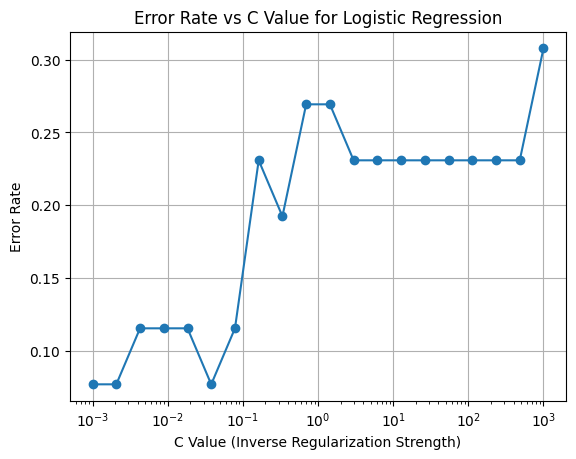

In [25]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

error_rates = []
C_values = np.logspace(-3, 3, 20)  # 20 values from 0.001 to 1000

for c in C_values:
    log_reg_temp = LogisticRegression(C=c, class_weight='balanced', max_iter=1000, random_state=42)
    log_reg_temp.fit(x_train, y_train)
    y_pred = log_reg_temp.predict(x_test)
    error = np.mean(y_pred != y_test)
    error_rates.append(error)

plt.plot(C_values, error_rates, marker='o')
plt.xscale('log')  # because C is logarithmic scale
plt.xlabel('C Value (Inverse Regularization Strength)')
plt.ylabel('Error Rate')
plt.title('Error Rate vs C Value for Logistic Regression')
plt.grid(True)
plt.show()
